<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Percent_Older_Adults_(65%2B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

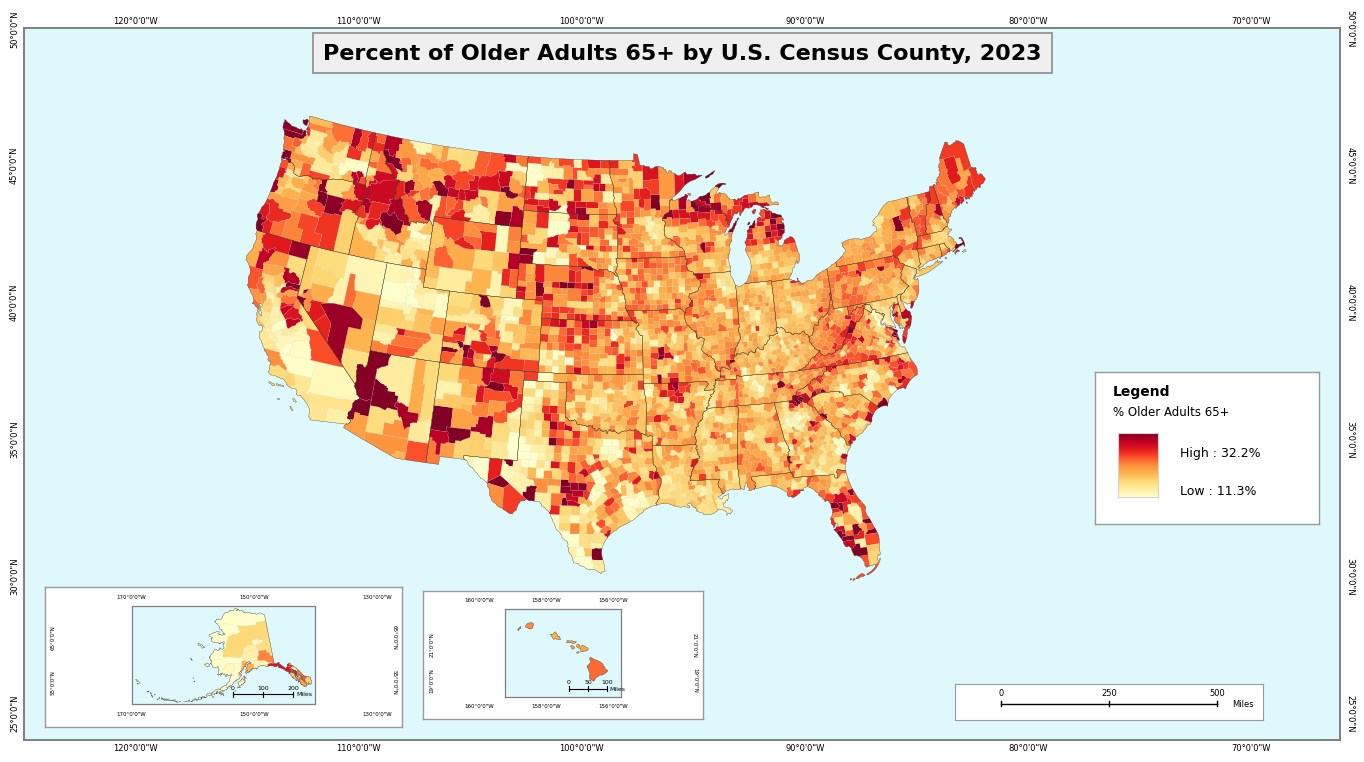

In [ ]:
# Open In Colab

# Link to download: https://data.census.gov/table/ACSDP5Y2023.DP05?q=population&g=010XX00US,$0500000

# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read Excel file
file = "/content/ACSDP5Y2023.DP05-2026-06-18T144252.xlsx"

acs_data = pd.read_excel(
    file,
    sheet_name="Data",
    header=None
)

# Find the row for "65 years and over"
older_row = acs_data[acs_data[0] == "65 years and over"].index[0]

# Every county starts at column 5, then repeats every 4 columns:
# Estimate, Margin of Error, Percent, Percent Margin of Error
county_columns = list(range(5, acs_data.shape[1], 4))

older_data = []

for col in county_columns:
    county_name = acs_data.iloc[0, col]
    percent_older = acs_data.iloc[older_row, col + 2]

    older_data.append({
        "county_state": county_name,
        "percent_older_adults": percent_older
    })

older_df = pd.DataFrame(older_data)

# Remove missing county names
older_df = older_df[older_df["county_state"].notna()].copy()

# Clean percent column
older_df["percent_older_adults"] = (
    older_df["percent_older_adults"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

older_df["percent_older_adults"] = pd.to_numeric(
    older_df["percent_older_adults"],
    errors="coerce"
)

# Split county and state from names like "Autauga County, Alabama"
older_df[["county", "state"]] = older_df["county_state"].str.rsplit(
    ", ",
    n=1,
    expand=True
)

# Read county shapefile
county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"

counties = gpd.read_file(county_url)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge county boundaries with older adults data
# Use NAMELSAD because it includes "County"
merged = counties.merge(
    older_df,
    left_on=["NAMELSAD", "STATE_NAME"],
    right_on=["county", "state"],
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Color scale
older_values = merged["percent_older_adults"].dropna()
vmin = older_values.quantile(0.02)
vmax = older_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STATEFP")
alaska_states = alaska_proj.dissolve(by="STATEFP")
hawaii_states = hawaii_proj.dissolve(by="STATEFP")

# Plot the percent-older-adults choropleth
def plot_older_adults_map(ax, gdf, linewidth):
    gdf.plot(
        column="percent_older_adults",
        cmap="YlOrRd",
        legend=False,
        edgecolor="lightgray",
        linewidth=linewidth,
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        missing_kwds={
            "color": "#eeeeee",
            "edgecolor": "lightgray",
            "linewidth": linewidth
        }
    )

# Convert decimal degrees to degree-minute-second format
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1

    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}°{minutes}'{seconds}\"{direction}"

# Add DMS labels only, without grid lines
def add_dms_frame_labels(
    ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6
):
    for lon in lon_values:
        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac,
            1.004,
            label,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            x_frac,
            -0.004,
            label,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

    for lat in lat_values:
        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            -0.004,
            y_frac,
            label,
            transform=ax.transAxes,
            ha="right",
            va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            1.004,
            y_frac,
            label,
            transform=ax.transAxes,
            ha="left",
            va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

# Add DMS labels between the outer and inner inset boxes
def add_inset_dms_labels(
    outer_ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    inner_left,
    inner_bottom,
    inner_width,
    inner_height,
    lon_fontsize=4.5,
    lat_fontsize=4.5
):
    for lon in lon_values:
        x_frac = inner_left + ((lon - lon_min) / (lon_max - lon_min)) * inner_width
        label = decimal_to_dms(lon, is_lon=True)

        outer_ax.text(
            x_frac,
            inner_bottom + inner_height + 0.05,
            label,
            transform=outer_ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

        outer_ax.text(
            x_frac,
            inner_bottom - 0.05,
            label,
            transform=outer_ax.transAxes,
            ha="center",
            va="top",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

    for lat in lat_values:
        y_frac = inner_bottom + ((lat - lat_min) / (lat_max - lat_min)) * inner_height
        label = decimal_to_dms(lat, is_lon=False)

        outer_ax.text(
            inner_left - 0.04,
            y_frac,
            s=label,
            transform=outer_ax.transAxes,
            ha="right",
            va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

        outer_ax.text(
            inner_left + inner_width + 0.04,
            y_frac,
            s=label,
            transform=outer_ax.transAxes,
            ha="left",
            va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

# Draw a simple visual scale bar in its own small box
def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles"):
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#9a9a9a")

    ax.set_xticks([])
    ax.set_yticks([])

    # Main scale line
    ax.plot([0.15, 0.85], [0.45, 0.45], color="black", linewidth=1.0)

    # Tick marks
    ax.plot([0.15, 0.15], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.50, 0.50], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.85, 0.85], [0.38, 0.52], color="black", linewidth=1.0)

    # Labels
    ax.text(0.15, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
    ax.text(0.50, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
    ax.text(0.85, 0.62, labels[2], ha="center", va="bottom", fontsize=6)
    ax.text(0.90, 0.45, unit, ha="left", va="center", fontsize=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Draw a tiny visual scale bar inside an inset map
def draw_small_inset_scale(ax, labels=("0", "100", "200")):
    ax.plot(
        [0.55, 0.88],
        [0.10, 0.10],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.plot(
        [0.55, 0.55],
        [0.075, 0.125],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.plot(
        [0.715, 0.715],
        [0.075, 0.125],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.plot(
        [0.88, 0.88],
        [0.075, 0.125],
        transform=ax.transAxes,
        color="black",
        linewidth=0.8,
        zorder=20
    )

    ax.text(
        0.55,
        0.145,
        labels[0],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=4.5,
        zorder=21
    )

    ax.text(
        0.715,
        0.145,
        labels[1],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=4.5,
        zorder=21
    )

    ax.text(
        0.88,
        0.145,
        labels[2],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=4.5,
        zorder=21
    )

    ax.text(
        0.895,
        0.10,
        "Miles",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=4.5,
        zorder=21
    )

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Background frame that fills the whole map layout
ax_frame_bg = fig.add_axes([0.025, 0.045, 0.94, 0.89], zorder=0)
ax_frame_bg.set_facecolor("#dff8fb")

for spine in ax_frame_bg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame_bg.set_xticks([])
ax_frame_bg.set_yticks([])

# Main lower 48 map
ax_main = fig.add_axes([0.045, 0.210, 0.805, 0.650], zorder=2)
ax_main.set_facecolor("#dff8fb")

# Plot percent-older-adults map
plot_older_adults_map(ax_main, lower48_proj, 0.08)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.18,
    zorder=4
)

# Keep main map centered and fitted
minx, miny, maxx, maxy = lower48_proj.total_bounds
x_buffer = (maxx - minx) * 0.030
y_buffer = (maxy - miny) * 0.060

ax_main.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_main.set_ylim(miny - y_buffer, maxy + y_buffer)

# Remove the inner main-map border so only the big outer border shows
for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska outer white box
ak_outer = fig.add_axes([0.040, 0.062, 0.255, 0.175], zorder=4)
ak_outer.set_facecolor("white")

for spine in ak_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ak_outer.set_xticks([])
ak_outer.set_yticks([])

# Alaska inner map box
ak_inner_left = 0.070
ak_inner_bottom = 0.160
ak_inner_width = 0.860
ak_inner_height = 0.700

ax_ak = ak_outer.inset_axes([
    ak_inner_left,
    ak_inner_bottom,
    ak_inner_width,
    ak_inner_height
])

ax_ak.set_facecolor("#dff8fb")

# Alaska labels between outer and inner boxes
add_inset_dms_labels(
    outer_ax=ak_outer,
    lon_values=[-170, -150, -130],
    lat_values=[55, 65],
    lon_min=-180,
    lon_max=-130,
    lat_min=50,
    lat_max=72,
    inner_left=ak_inner_left,
    inner_bottom=ak_inner_bottom,
    inner_width=ak_inner_width,
    inner_height=ak_inner_height,
    lon_fontsize=4,
    lat_fontsize=4
)

plot_older_adults_map(ax_ak, alaska_proj, 0.10)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.20,
    zorder=4
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.02
y_buffer = (maxy - miny) * 0.02

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Small Alaska scale bar
draw_small_inset_scale(ax_ak, labels=("0", "100", "200"))

# Hawaii outer white box
hi_outer = fig.add_axes([0.310, 0.072, 0.200, 0.160], zorder=4)
hi_outer.set_facecolor("white")

for spine in hi_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

hi_outer.set_xticks([])
hi_outer.set_yticks([])

# Hawaii inner map box
hi_inner_left = 0.080
hi_inner_bottom = 0.165
hi_inner_width = 0.840
hi_inner_height = 0.690

ax_hi = hi_outer.inset_axes([
    hi_inner_left,
    hi_inner_bottom,
    hi_inner_width,
    hi_inner_height
])

ax_hi.set_facecolor("#dff8fb")

# Hawaii labels between outer and inner boxes
add_inset_dms_labels(
    outer_ax=hi_outer,
    lon_values=[-160, -158, -156],
    lat_values=[19, 21],
    lon_min=-161,
    lon_max=-154,
    lat_min=18,
    lat_max=23,
    inner_left=hi_inner_left,
    inner_bottom=hi_inner_bottom,
    inner_width=hi_inner_width,
    inner_height=hi_inner_height,
    lon_fontsize=4,
    lat_fontsize=4
)

plot_older_adults_map(ax_hi, hawaii_proj, 0.10)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.20,
    zorder=4
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Small Hawaii scale bar
draw_small_inset_scale(ax_hi, labels=("0", "50", "100"))

# Main scale bar in bottom-right corner
ax_scale = fig.add_axes([0.690, 0.070, 0.220, 0.045], zorder=4)
draw_scale_box(ax_scale, labels=("0", "250", "500"), unit="Miles")

# Legend box
ax_leg = fig.add_axes([0.790, 0.315, 0.160, 0.190], zorder=4)
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Legend title
ax_leg.text(
    0.08,
    0.92,
    "Legend",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top"
)

ax_leg.text(
    0.08,
    0.78,
    "% Older Adults 65+",
    fontsize=8.5,
    ha="left",
    va="top"
)

# Gradient color scale inside legend
scale_ax = ax_leg.inset_axes([0.10, 0.18, 0.18, 0.42])

gradient = np.linspace(vmax, vmin, 256).reshape(256, 1)

scale_ax.imshow(
    gradient,
    aspect="auto",
    cmap="YlOrRd"
)

scale_ax.set_xticks([])
scale_ax.set_yticks([])

for spine in scale_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("lightgray")

# High / Low labels
ax_leg.text(
    0.38,
    0.47,
    f"High : {vmax:.1f}%",
    fontsize=9,
    ha="left",
    va="center"
)

ax_leg.text(
    0.38,
    0.22,
    f"Low : {vmin:.1f}%",
    fontsize=9,
    ha="left",
    va="center"
)

# Transparent top frame for border, coordinate labels, and title
ax_frame = fig.add_axes([0.025, 0.045, 0.94, 0.89], zorder=10)
ax_frame.patch.set_alpha(0)

for spine in ax_frame.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame.set_xticks([])
ax_frame.set_yticks([])

# DMS coordinate labels around the whole map layout
add_dms_frame_labels(
    ax=ax_frame,
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    lon_fontsize=6,
    lat_fontsize=6
)

# Title inside the big frame
ax_frame.text(
    0.5,
    0.965,
    "Percent of Older Adults 65+ by U.S. Census County, 2023",
    transform=ax_frame.transAxes,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=20
)

plt.show()